# Lesson 187 · Ethics & privacy on REG

Complete course experiment, not a private-GNN benchmark. Tier B: full public F1 relational snapshot. The notebook embeds all nine tables and four figures. Python3, numpy, pandas, pyarrow and duckdb are required; install missing packages before running. No cloud service or download is used by the lab. Live Colab UI is NOT_CHECKED.

Three TODOs are live: ownership, contribution bounding, noise/accounting. Author-reference results below do not represent your completed work.

In [ ]:
# @colab-bootstrap
from pathlib import Path
import base64,hashlib,io,json,math,zipfile
import numpy as np
import pandas as pd
import pyarrow,duckdb
print("Public seeded simulator; cloud/API $0; no production DP claim")

## Your tangible win

Write a release contract that answers **whose information changes, which records change, and what an observer receives**. Then implement and audit a complete contribution-bounded histogram experiment. This supports the mission: a relational model's useful connections also create obligations that a flat-row evaluation can miss.

**Author evidence:** complete `L187-F1-ENTITY-PRIVACY` course experiment. All 857 drivers, 2,571 histogram neighbors and 270 simulated releases checked. Published private-GNN reproduction **NOT_RUN**; production DP and complete erasure **NOT_ESTABLISHED**. Learner **PENDING_WRITTEN_DEFENSE**.

## Recall before reading

Recall: why does time filtering differ from target masking? What is a foreign key? Write the answers before continuing.

**Bridge from earlier work.** [Lesson 156](https://avistian.github.io/relational/lessons/0156-temporal-leakage-audit.html) asked whether information existed at prediction time. [Lesson 181](https://avistian.github.io/relational/lessons/0181-relbench-v2-autocomplete.html) asked which target cells a model could see. This lesson asks what publishing an answer can reveal about a person. A time-valid, correctly masked model can still expose personal information. [Lesson 186](https://avistian.github.io/relational/lessons/0186-production-constraints.html) added deadlines and freshness to the serving contract. Here we add what the response may reveal. The needed prerequisites are restated below; its simulator is not required.

## 1 · A person is not necessarily one node

**Relational entity graph (REG).** Represent each table row as a node. Represent each foreign-key reference as an edge. A foreign key is a column pointing to another table's row identity. One person can be represented by a profile row and many event rows. Graph-node privacy depends on this representation; it does not automatically mean person-level privacy.

**Threat model.** State what an observer already knows, what you release, and what they try to infer. Here the observer sees a constructor-count vector and may know public race metadata. The protected change will be one driver's declared contribution. We are not trying to hide public race names, nor promising to conceal every fact correlated with a driver's existence.

Predict: will deleting only the driver graph node remove all event records? Give a reason before reading on.

**Worked example.** Driver A owns a profile, three result rows, one qualifying row and two standings rows: seven nodes in total. Each result and qualifying row has three foreign keys; each standings row has two. There are 16 edges touching the declared owned set. Six point directly to the driver profile.

<figure class="route-figure" tabindex="0">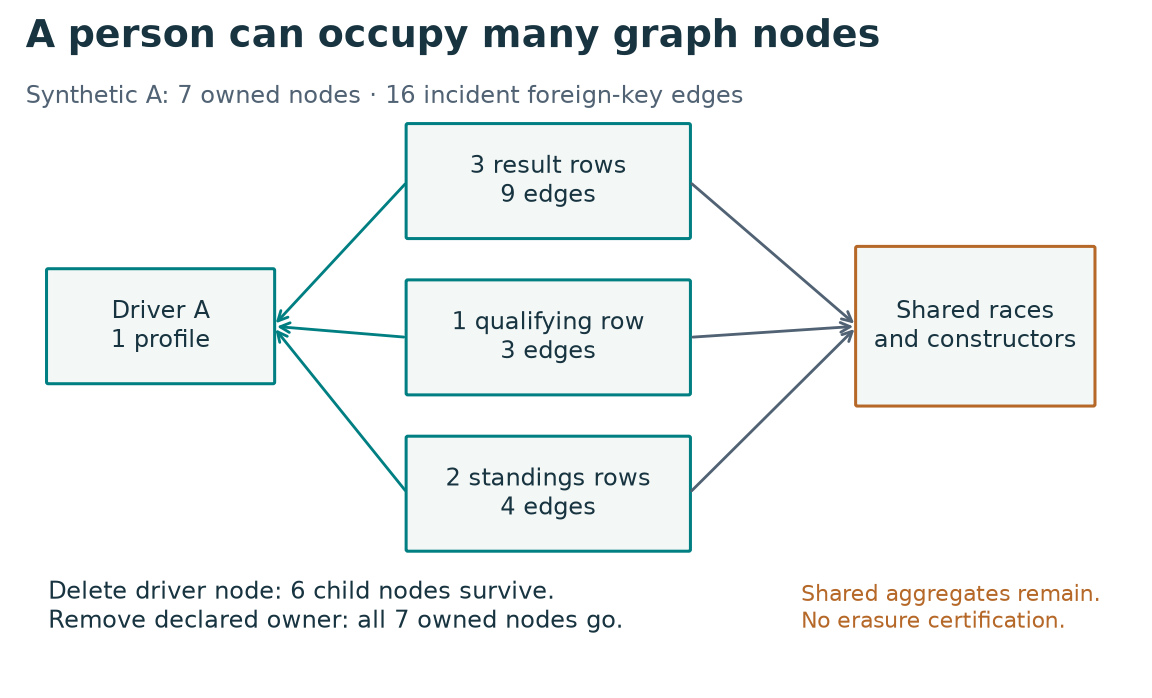<figcaption>Synthetic ownership map: each arrow bundles foreign-key edges. Standings connect to races and the driver, not constructors. Deleting the profile leaves child nodes; declared owner removal still retains shared context.</figcaption></figure>

Try the three removal operations using the ownership functions below. Default graph-node removal leaves six child nodes in the synthetic example.

Deleting one result row removes that row and its three edges. Deleting the driver **graph node** removes the profile and its six incident edges, leaving six child nodes connected to shared context. In an SQL database, foreign-key constraints can reject parent-only deletion; cascades depend on schema configuration. Neither behavior should be guessed from a graph diagram.

**Declared entity removal** deletes the profile and all rows directly owned through `driverId` in results, qualifying and standings. It retains shared races, circuits, constructors and constructor aggregate tables. This is an explicit course policy, not a discovery that those are all possible traces of the person. A model checkpoint, a log, a backup or a constructor's historical points may retain derived information.

> **Scope check.** Node deletion, contribution removal, anonymization and model unlearning are different operations. We execute the second under a declared ownership map. We do not certify complete erasure or retrain a model.

## 2 · Four questions that “no leakage” cannot answer

| Question | Example | Appropriate evidence |
|---|---|---|
| Was future information used? | Tomorrow's result enters today's context | Availability and temporal audit |
| Can a person be linked to records? | Removing names leaves distinctive relationships | Linkage threat model and disclosure audit |
| Can participation be inferred? | An output differs when one person is included | Membership attack plus a separate privacy analysis |
| Is the use acceptable? | A permitted prediction is used for a harmful purpose | Purpose, authority, affected-person review and recourse |

An unsuccessful membership attack only tests that attack under its assumptions. It does not establish a universal privacy guarantee. Conversely, a population-level fact may be learnable even with a private mechanism. Privacy also does not establish fairness: a model can protect participation while producing systematically harmful decisions.

**Ethics decision exercise.** Imagine replacing the public F1 records with patients, visits and hospitals. A researcher proposes releasing hospital counts and retaining embeddings for future projects. Before choosing a noise level, write the intended benefit, the permission or authority for that use, the minimum necessary fields, who can see each output, and a route to challenge harmful use. Explain why public availability or technical access alone would not settle those choices. This is a research-design exercise, not legal advice or a compliance certification.

## 3 · Fix the neighboring databases before the noise

> **In plain terms.** A privacy guarantee limits how much the released answer's distribution can change when one protected contribution is added or removed. You must first define that contribution.

Call two databases **neighbors** when one contains one additional driver's complete declared contribution and everything else is fixed. Stable driver and row identities remain unchanged for other people. Shared metadata is fixed. This is **add/remove adjacency**. Replacing one driver's whole contribution can instead require a bound of 2C below.

For a randomized mechanism M and every output event S, pure ε-differential privacy requires:

`Pr[M(D) ∈ S] ≤ exp(ε) × Pr[M(D′) ∈ S]`

Here D and D′ are neighbors, `Pr` is probability over the mechanism's hidden randomness, `exp` is the exponential function, and ε (epsilon) controls the allowed multiplicative change. The inequality must hold in both directions because neighboring is symmetric. Smaller ε is a stronger restriction. This is a distributional statement over all allowed neighbors and events, not a bound on one sampled output difference. See [Dwork and Roth, Definition 2.4](https://www.cis.upenn.edu/~aaroth/Papers/privacybook.pdf#page=20).

**Our query.** Count result rows in each constructor category. A histogram is the vector of these counts. Its category list is all 211 constructor IDs from the pinned **public** snapshot, fixed across neighboring datasets. A private category list must not be discovered and published for free. Our count mechanism reads only result IDs, driver IDs and constructor IDs; changes to other declared owned tables do not enter that query.

**Worked example.** A's result sequence is Red, Red, Blue; B has Blue. The raw histogram is `[2, 2]`. Keep at most C = 2 results per driver, ordered by immutable result ID. The clipped histogram is `[2, 1]`. Removing A produces `[0, 1]`: the whole vector changes by two counts.

**Why the cap is across bins.** Allowing C contributions *per constructor* would let one driver affect many bins, exceeding the claimed total bound. Sorting must be local to each owner; deleting A must not change which of B's rows survive. Our deterministic first-events rule is auditable but changes the scientific quantity: it emphasizes earlier results in the snapshot.

<figure class="route-figure" tabindex="0">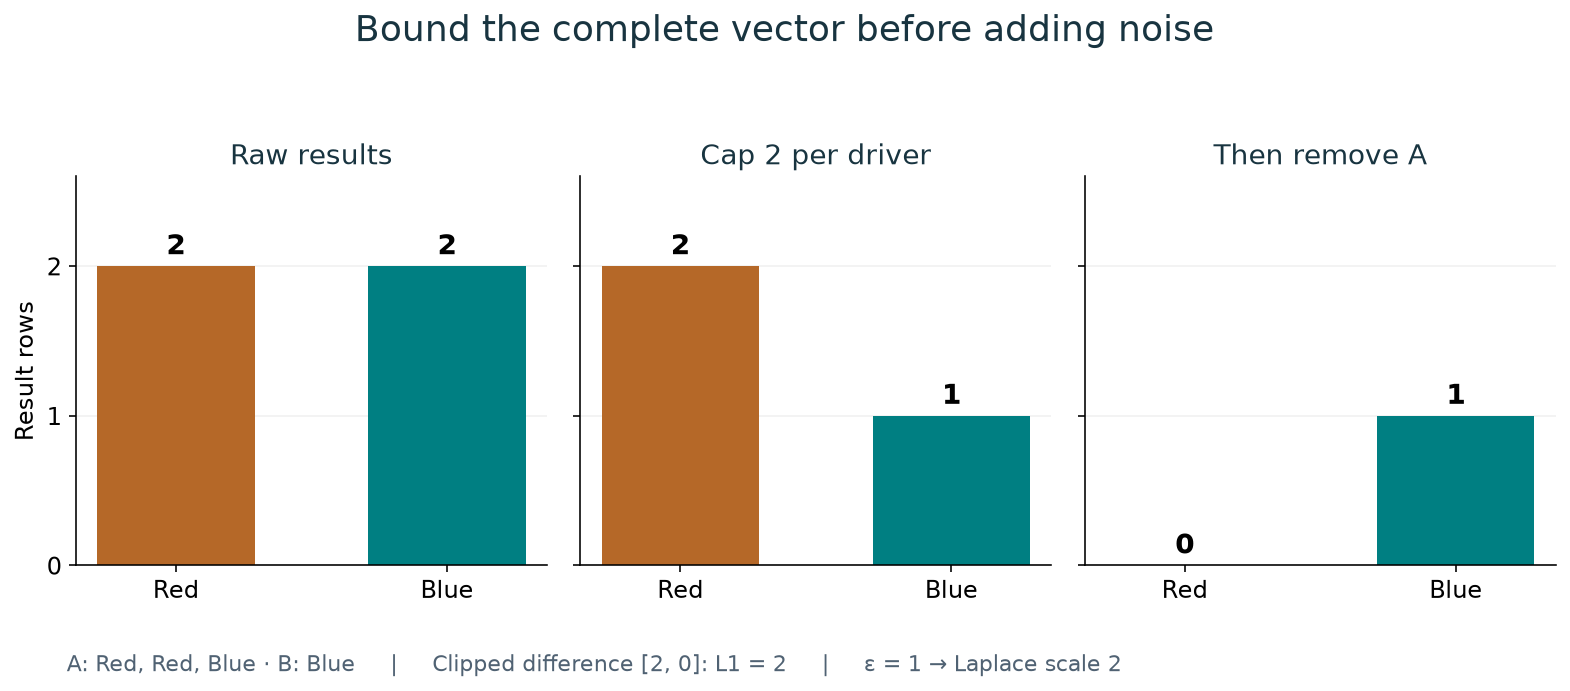<figcaption>Synthetic Red/Blue worked example: cap 2 reduces [2,2] to [2,1]. Removing A changes the clipped vector by [2,0], whose L1 norm is 2. At epsilon 1 the ideal Laplace scale is 2.</figcaption></figure>

## 4 · Derive the bound, then choose the mechanism

**L1 distance** adds the absolute coordinate differences between two vectors. **Global sensitivity** is the largest such query difference over all allowed neighboring databases, not just the largest difference observed in this snapshot.

Each retained result adds one to exactly one bin. A driver's retained rows therefore form a nonnegative vector whose coordinates sum to at most C. Other drivers' vectors are unchanged by removal. The histogram difference has L1 norm at most C. This argument holds for every database in the declared domain; the 2,571 actual deletion checks test the implementation but do not replace the argument.

**Laplace mechanism.** Add independent Laplace noise to every bin with scale `b = C / ε`. This symmetric noise has density proportional to `exp(−|z|/b)` and expected absolute magnitude b. For two neighboring query vectors, the density ratio at any output is at most `exp(||f(D)−f(D′)||₁/b) ≤ exp(ε)`. Integrating over output events yields the required inequality. The scale uses the **whole vector's sensitivity**; this is one vector release, not 211 separately budgeted scalar queries. [Dwork and Roth, Definition 3.4 and Theorem 3.6](https://www.cis.upenn.edu/~aaroth/Papers/privacybook.pdf#page=34).

At C = 2 and ε = 1, the scale is two counts per coordinate. Noise can yield fractional or negative counts. We retain those values in the experiment so their error is transparent. Rounding or clamping an already private release is post-processing, but changes utility. It cannot fix a wrong sensitivity bound.

<figure class="route-figure" tabindex="0">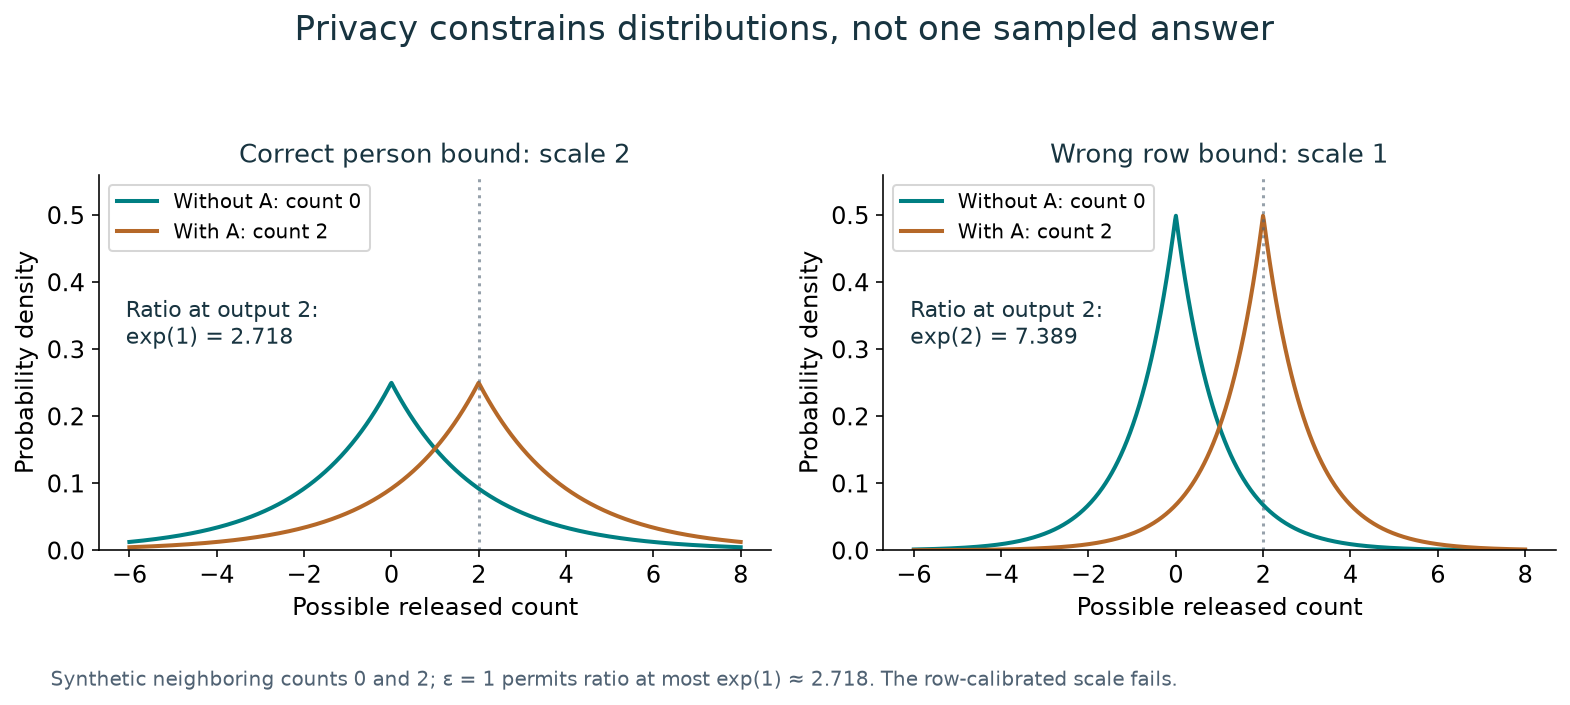<figcaption>Synthetic Laplace density comparison for neighboring scalar counts 0 and 2. At epsilon 1, scale 2 attains ratio exp(1); the incorrect row-calibrated scale 1 permits ratio exp(2). The full-vector proof is in the text.</figcaption></figure>

Try C = 1, 2, 3 and epsilon = 0.5, 1, 2 on the Red/Blue example. Derive the clipped vector and noise scale first.

**Repeated releases.** Fresh answers for the same population reveal more. Basic sequential composition adds their ε values. Thirty independent ε = 1 releases have an upper bound of ε = 30, not ε = 1. Re-reading the exact same released answer costs nothing extra. Our nine configurations with 30 repetitions would have basic bound **315** if they were genuine private mechanisms released together. They are public simulations, so that number is an accounting exercise, not their privacy certification. [Dwork and Roth, Corollary 3.15](https://www.cis.upenn.edu/~aaroth/Papers/privacybook.pdf#page=46).

> **Scope check.** The proof is for ideal hidden randomness and real arithmetic. The notebook intentionally publishes the raw data, seeds and float64 outputs. An observer who knows the noise can subtract it. This implementation is an inspectable simulator, not a production differential-privacy service; finite-precision sampling also requires a separate analysis.

## 5 · Complete experiment, visible limitations

**Held fixed:** all nine F1 tables, all drivers, the public constructor domain, stable ownership, row-ID ordering and the full results population. **Varied:** C ∈ {1, 5, 20}, ε ∈ {0.5, 1, 2}, seeds 0–29. **Measured:** owned records and edges, deletion effects, clipping loss, noise error and error against the original histogram. There is no training, hyperparameter selection or temporal forecasting claim. All dates belong to a static descriptive snapshot.

**Predict first.** Will a larger cap always reduce error relative to the original histogram? Write down the two competing effects: retaining more records reduces clipping loss, while the same ε requires more noise.

The full nine-table snapshot contains **70,876 declared owned records** and **175,933 edges incident to those owned sets**. Driver ID 3 has the largest contribution: **370 results + 353 qualifying + 372 standings + 1 driver = 1,096 records**. These IDs are snapshot identities, not names inferred by an attack.

| Cap C | ε | Kept / 26,080 | Clipping L1 | Noise MAE ± SD | Raw MAE ± SD |
|---:|---:|---:|---:|---:|---:|
| 1 | 0.5 | 857 | 25,223 | 1.997 ± 0.124 | 119.977 ± 0.150 |
| 1 | 1 | 857 | 25,223 | 1.006 ± 0.058 | 119.720 ± 0.099 |
| 1 | 2 | 857 | 25,223 | 0.498 ± 0.044 | 119.587 ± 0.039 |
| 5 | 0.5 | 3,135 | 22,945 | 10.209 ± 0.662 | 113.344 ± 0.951 |
| 5 | 1 | 3,135 | 22,945 | 4.973 ± 0.337 | 110.636 ± 0.378 |
| 5 | 2 | 3,135 | 22,945 | 2.397 ± 0.164 | 109.623 ± 0.192 |
| 20 | 0.5 | 8,260 | 17,820 | 39.891 ± 2.555 | 110.678 ± 2.745 |
| 20 | 1 | 8,260 | 17,820 | 20.253 ± 1.415 | 96.531 ± 1.481 |
| 20 | 2 | 8,260 | 17,820 | 9.897 ± 0.651 | 89.770 ± 0.797 |


**Read the columns carefully.** Clipping L1 is the total number of discarded results. Noise MAE is mean absolute error per constructor relative to the clipped query. Raw MAE compares the release with the original full histogram. The table reports mean ± sample standard deviation across 30 seeds; it is descriptive simulation variation, not uncertainty across new databases or a privacy proof.

<figure class="route-figure" tabindex="0">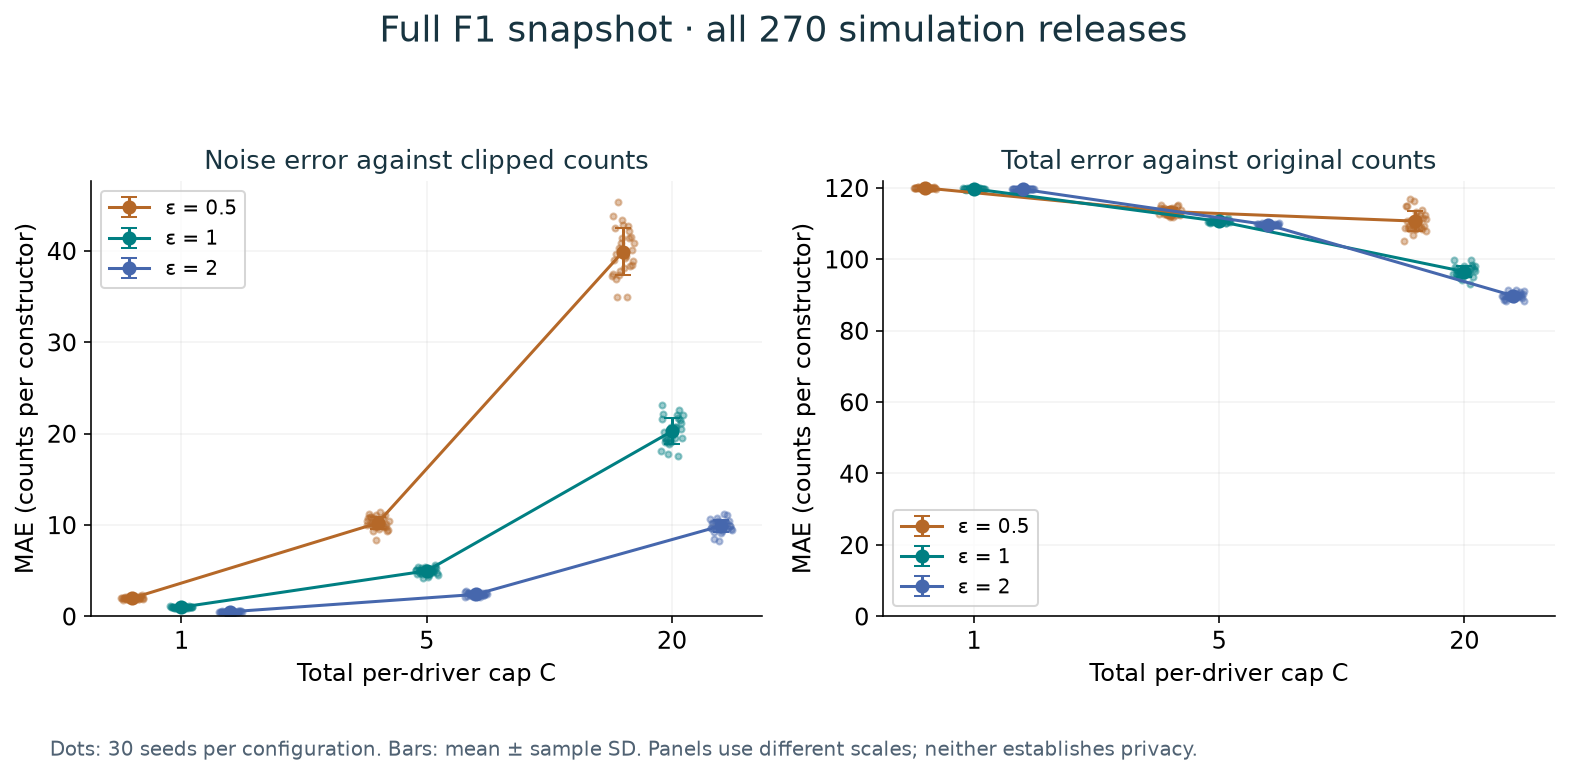<figcaption>Measured full F1 simulation. All 270 seeds/configuration runs shown; means and sample standard deviations describe simulation variation. Different panel scales are explicit. Public data and seeds confer no production privacy guarantee.</figcaption></figure>

The local verifier independently checks all primary/foreign keys, ownership counts with SQL, every driver deletion at all three caps, every saved vector and scalar error calculation. The [full evidence](https://avistian.github.io/relational/labs/evidence/l187/report.json), [driver audit](https://avistian.github.io/relational/labs/evidence/l187/driver-audit.csv), [verification receipt](https://avistian.github.io/relational/labs/_verify_l187_results.json) and [frozen protocol](https://avistian.github.io/relational/labs/l187-reproduction.md) preserve exact results.

**The erasure boundary is measured too.** Shared constructor-result aggregates are joined through race and constructor keys to 24,501 distinct driver/aggregate pairs in this snapshot. These are retained relationships, not 24,501 proven attacks. They demonstrate why a direct foreign-key ownership policy does not establish removal of every derived trace.

## 6 · What changes for a GNN?

A graph neural network mixes a node's features with its neighbors' features. Removing one person can therefore change messages used in several predictions and gradient computations. Clipping each training row as if the examples were independent is not automatically a person-level proof. The protected unit, sampling, message dependencies, preprocessing, training and inference access all need accounting.

[GAP](https://arxiv.org/abs/2203.00949) proposes noisy aggregation for private graph learning. [Xiang, Wang and Wang, v2 §VI](https://arxiv.org/html/2311.06888v2) report flaws in the privacy treatment of instance embeddings and analyze GAP's aggregation noise. Attribute that finding to their analysis. Neither their critique nor reproducing an accuracy table is a new local privacy proof.

> **Scope check.** This lesson does not implement GAP or HeterPoisson, train a private GNN, or reproduce their published benchmarks. Full execution here means the named course audit and histogram experiment. Paper reproduction remains `NOT_RUN`. A private histogram also does not privatize a model trained on the original graph.

## 7 · Implement, explain, return later

Open the [student notebook](https://avistian.github.io/relational/labs/0187-ethics-privacy-reg.ipynb), [executed walkthrough](https://avistian.github.io/relational/labs/html/0187-ethics-privacy-reg.html), or [solution](https://avistian.github.io/relational/labs/solutions/0187-ethics-privacy-reg.ipynb). The lab contains all input tables with hashes, readable functions, three live TODOs and an independent verifier. Implement ownership counting, stable per-person clipping and the scale/composition contract. Checks call your functions on synthetic counterexamples and then on the complete dataset.

**EXIT:** explain why the largest owner has 1,096 records; derive C rather than asserting it; distinguish count error from privacy; explain why publishing the seed changes the release contract; and defend one ethically acceptable use with an explicit limitation. Send the written defense and check output to the teaching agent. Author execution does not establish your mastery.

Use the EXIT fields below to explain the mechanism in your own words.

**Spaced return.** Tomorrow, derive the scale without looking. In one week, change the policy to per-category clipping and find a counterexample. Compare a time-valid but privacy-unsafe release with a noisy release whose intended use is still unacceptable.

**Primary reading:** [Dwork and Roth](https://www.cis.upenn.edu/~aaroth/privacybook.html), definitions and Laplace/composition sections linked above. Use the [privacy contract reference](https://avistian.github.io/relational/reference/ethics-privacy-reg.html) when auditing another database. Ask follow-up questions wherever the ownership map or proof feels unclear.

**Next: [Lesson 188](https://avistian.github.io/relational/lessons/0188-systematic-literature-tracking.html).** Carry the distinction between a reported result and an established guarantee into your paper log. Record what each source actually supports before choosing a research direction.


## PROVIDED · Authenticate the complete input packet
The fixed public constructor domain is taken from this authenticated snapshot and held fixed across neighbors. SHA256 verifies bytes, not correctness of the privacy claim.

In [ ]:
PACKET='...'
raw=base64.b64decode(PACKET)
assert hashlib.sha256(raw).hexdigest()=='1f5a31aa575418a3d6b0c876cb288da08808069f682c83cab235af48a5806f04'
packet=Path('l187-packet');packet.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist():assert not Path(name).is_absolute() and '..' not in Path(name).parts
    z.extractall(packet)
manifest={'source_revision': '0d47fe0c8a1a51aaf97ab485f4a028e290f97c67', 'historical_identity': 'NOT_ESTABLISHED', 'inherited_manifest_sha256': '2a7a46fcf7f69b1d6c7eba37c83778ca33921582e85d6d584562420ef2c16f39', 'files': {'config.json': '128deac20cf7ad4cd0977443913eac9bde7e53c1565d4a66a34542904e30bc3d', 'db/circuits.parquet': 'c36c6537b9c5c9985ec438110717e93289085a5bffbcee07d08bbe1771994d8d', 'db/constructor_results.parquet': '35582c2f0634d5503b664babf38264311332e6ca3cb612fb0fe737bfaffdc29e', 'db/constructor_standings.parquet': '739fc21ba301ef2081dbd8e56d643f148b672224a4d223b95d6107ccd735aa6b', 'db/constructors.parquet': 'fc79dd346430186cdca6263e1c532891bf4d4ba7463fd94b398350a9356180c6', 'db/drivers.parquet': 'ba3461b83a1a467a856bde4059519140a5a31952ad24a5e944ea9dd5c5faceae', 'db/qualifying.parquet': '2d5cb7b4ed6cf4076b74ab1cc79f5f35faf31b7f032b51d2a1ac814e1d0c834b', 'db/races.parquet': '88bb260f03c9ec5c7b030969d7284531d5f8e8592d73174686ad01cdfc8f87ea', 'db/results.parquet': 'b8b0e39b27f318a7bd461f21bb0ba9ef44909ed569d287e0c6b2969c6bd2f598', 'db/standings.parquet': 'f3f6a34fee190f077f2fe48026a7e5659e4c91a34f72340cdff3cf407c1f3534'}}

In [ ]:
def load187(packet, manifest):
    for name,digest in manifest['files'].items():
        if hashlib.sha256((packet/name).read_bytes()).hexdigest()!=digest:
            raise ValueError('Input hash mismatch: '+name)
    return {p.stem:pd.read_parquet(p) for p in sorted((packet/'db').glob('*.parquet'))}

In [ ]:
db=load187(packet,manifest)
config=json.loads((packet/'config.json').read_text())
print(pd.DataFrame([{'table':k,'rows':len(v)} for k,v in db.items()]).to_string(index=False))

## TODO · Count the declared contribution
Input is a dictionary of tables. Return one row per driver in sorted driverId order with results, qualifying and standings counts, owned_rows (including profile), driver_incident_edges and owned_incident_edges. Results and qualifying have three foreign keys; standings has two. Reject missing, duplicate driver identities or unknown child owners.

In [ ]:
def owned_counts(db):
    raise NotImplementedError("Implement owned_counts")

### CHECK · Count the declared contribution

In [ ]:
tiny={'drivers':pd.DataFrame({'driverId':[1,2]}),'results':pd.DataFrame({'driverId':[1,1]}),'qualifying':pd.DataFrame({'driverId':[1]}),'standings':pd.DataFrame({'driverId':[2]})}
assert owned_counts(tiny).owned_rows.tolist()==[4,2]
print('Immediate CHECK passed')

## TODO · Bound the whole owner contribution
Input events have resultId, driverId and constructorId. Keep at most cap total rows per driver using ascending immutable resultId. Return an integer vector in the fixed domain order, including zero bins. Reject nonpositive/noninteger caps, duplicate row IDs, missing keys, repeated or unknown categories. Removing an owner must not change another owner's retained rows.

In [ ]:
def bounded_histogram(events, domain, cap):
    raise NotImplementedError("Implement bounded_histogram")

### CHECK · Bound the whole owner contribution

In [ ]:
toy=pd.DataFrame({'resultId':[1,2,3,4],'driverId':[1,1,1,2],'constructorId':[10,10,20,20]})
assert np.array_equal(bounded_histogram(toy,[10,20,30],2),[2,1,0])
assert np.array_equal(bounded_histogram(toy.iloc[::-1],[10,20,30],2),[2,1,0])
print('Immediate CHECK passed')

## TODO · Connect the mechanism to its privacy unit
Return a dictionary with scale and epsilon_total for cap, epsilon and repeats. Derive scale from the complete vector sensitivity. The repeats count describes fresh independent releases on the same people, not re-reading an answer. Reject invalid integer caps/repeats and nonpositive/nonfinite epsilon.

In [ ]:
def release_scale(cap, epsilon, repeats=1):
    raise NotImplementedError("Implement release_scale")

### CHECK · Connect the mechanism to its privacy unit

In [ ]:
assert release_scale(2,1,5)=={'scale':2.,'epsilon_total':5.}
print('Immediate CHECK passed')

## CHECK · Adversarial contracts
Unknown owners, duplicated identities, missing bins, invalid budgets and order dependence must fail. These fixtures exercise the actual learner functions.

In [ ]:
def checks(owned_counts, bounded_histogram, release_scale):
    db={'drivers':pd.DataFrame({'driverId':[7,9,11]}),
        'results':pd.DataFrame({'driverId':[7,7,9]}),
        'qualifying':pd.DataFrame({'driverId':[7]}),
        'standings':pd.DataFrame({'driverId':[9,9]})}
    out=owned_counts(db).set_index('driverId')
    assert list(out.loc[[7,9,11],'owned_rows'])==[4,4,1], 'Count each owned record, including driver'
    e=pd.DataFrame({'resultId':[4,1,3,2,5], 'driverId':[7,7,9,7,9], 'constructorId':[20,10,20,20,10]})
    h=bounded_histogram(e,[10,20,30],2)
    assert np.array_equal(h,[2,2,0]), 'Cap total rows per owner, keep public zero bin'
    assert np.array_equal(h,bounded_histogram(e.iloc[::-1],[10,20,30],2)), 'Stable row ID order'
    assert np.array_equal(bounded_histogram(e[e.driverId!=7],[10,20,30],2),[1,1,0])
    assert np.array_equal(bounded_histogram(e.iloc[:0],[10,20,30],2),[0,0,0])
    assert release_scale(5,.5,3)=={'scale':10.,'epsilon_total':1.5}
    bad_calls=[lambda:bounded_histogram(e,[10,10,20],2),lambda:bounded_histogram(e,[10],2),
        lambda:bounded_histogram(pd.concat([e,e.iloc[:1]]),[10,20],2),
        lambda:bounded_histogram(e,[10,20],0),lambda:bounded_histogram(e,[10,20],1.5),
        lambda:release_scale(1,0),lambda:release_scale(1,float('nan')),
        lambda:release_scale(1,1,0),lambda:release_scale(1,1,1.5),
        lambda:owned_counts({**db,'results':pd.DataFrame({'driverId':[999]})})]
    for call in bad_calls:
        try:call()
        except ValueError:pass
        else:raise AssertionError('Invalid privacy contract accepted')
    return 'PASS'

In [ ]:
assert checks(owned_counts,bounded_histogram,release_scale)=='PASS'

## PROVIDED · Execute all nine configurations × 30 seeds
No subsampling, training or HPO. Each bin retains a float64 noisy count; negative values are not clamped. Noise MAE uses the clipped query; raw MAE uses the original full histogram. All randomness is public and reproducible.

In [ ]:
def experiment187(db, config, owned_counts, bounded_histogram, release_scale):
    if config['caps']!=[1,5,20] or config['epsilons']!=[.5,1.,2.] or config['seeds']!=list(range(30)):
        raise ValueError('Changed frozen experiment')
    counts=owned_counts(db)
    events=db['results'];domain=sorted(db['constructors'].constructorId.tolist())
    raw=events.constructorId.value_counts().reindex(domain,fill_value=0).to_numpy(dtype=np.int64)
    releases=[];summaries=[];histograms={}
    for cap in config['caps']:
        clipped=bounded_histogram(events,domain,cap);histograms[str(cap)]=clipped.tolist()
        for epsilon in config['epsilons']:
            spec=release_scale(cap,epsilon,30);noise_mae=[];raw_mae=[]
            for seed in config['seeds']:
                rng=np.random.default_rng(np.random.SeedSequence([187,cap,int(epsilon*10),seed]))
                noise=rng.laplace(0,spec['scale'],len(domain));released=clipped+noise
                a=float(np.mean(np.abs(released-clipped)));b=float(np.mean(np.abs(released-raw)))
                releases.append({'cap':cap,'epsilon':epsilon,'seed':seed,'values':released.tolist(),
                                 'mae_clipped':a,'mae_raw':b})
                noise_mae.append(a);raw_mae.append(b)
            summaries.append({'cap':cap,'epsilon':epsilon,'scale':spec['scale'],
                'kept':int(clipped.sum()),'clipping_l1':int(np.abs(clipped-raw).sum()),
                'signed_bias_per_bin':float((clipped-raw).mean()),
                'noise_mae_mean':float(np.mean(noise_mae)),'noise_mae_sd':float(np.std(noise_mae,ddof=1)),
                'raw_mae_mean':float(np.mean(raw_mae)),'raw_mae_sd':float(np.std(raw_mae,ddof=1))})
    maximal=counts.sort_values(['owned_rows','driverId'],ascending=[False,True]).iloc[0]
    report={'experiment':config['experiment'],'status':'COMPLETE_COURSE_EXPERIMENT',
        'tables':{k:len(v) for k,v in db.items()},'drivers':len(counts),'owned_rows':int(counts.owned_rows.sum()),
        'driver_edges':int(counts.driver_incident_edges.sum()),'owned_edges':int(counts.owned_incident_edges.sum()),
        'maximum_owner':{k:int(v) for k,v in maximal.to_dict().items()},
        'domain':domain,'raw_histogram':raw.tolist(),'clipped_histograms':histograms,'summaries':summaries,
        'releases':len(releases),'released_coordinates':len(releases)*len(domain),
        'hypothetical_basic_composition_epsilon':float(30*3*sum(config['epsilons'])),
        'whole_paper':'NOT_RUN','production_dp':'NOT_ESTABLISHED','erasure':'NOT_ESTABLISHED',
        'learner':'PENDING_WRITTEN_DEFENSE','cloud_usd':0}
    return report,counts,releases

In [ ]:
report,counts,releases=experiment187(db,config,owned_counts,bounded_histogram,release_scale)
Path('l187-report.json').write_text(json.dumps(report,indent=2))
print(report['status'],report['releases'],'vectors',report['released_coordinates'],'coordinates')
print(pd.DataFrame(report['summaries']).round(4).to_string(index=False))

## CHECK · Independent full-population route
SQL checks ownership, scalar Python checks histograms and errors, and every actual owner-deletion neighbor is recomputed. These are implementation checks, distinct from the symbolic global-sensitivity proof.

In [ ]:
def independent187(db, report, counts, releases, bounded_histogram):
    schema={'circuits':('circuitId',{}),'constructors':('constructorId',{}),'drivers':('driverId',{}),
        'races':('raceId',{'circuitId':'circuits'}),
        'results':('resultId',{'driverId':'drivers','raceId':'races','constructorId':'constructors'}),
        'qualifying':('qualifyId',{'driverId':'drivers','raceId':'races','constructorId':'constructors'}),
        'standings':('driverStandingsId',{'driverId':'drivers','raceId':'races'}),
        'constructor_results':('constructorResultsId',{'raceId':'races','constructorId':'constructors'}),
        'constructor_standings':('constructorStandingsId',{'raceId':'races','constructorId':'constructors'})}
    assert set(db)==set(schema)
    edges=0;fk_columns=0
    for name,(pk,fks) in schema.items():
        frame=db[name];assert frame[pk].notna().all() and frame[pk].is_unique
        for fk,parent in fks.items():
            assert frame[fk].notna().all() and frame[fk].isin(db[parent][schema[parent][0]]).all(),(name,fk)
            edges+=len(frame);fk_columns+=1
    con=duckdb.connect()
    for name,frame in db.items():con.register(name,frame)
    sql=con.execute('''SELECT d.driverId,
        (SELECT count(*) FROM results r WHERE r.driverId=d.driverId) results,
        (SELECT count(*) FROM qualifying q WHERE q.driverId=d.driverId) qualifying,
        (SELECT count(*) FROM standings s WHERE s.driverId=d.driverId) standings
        FROM drivers d ORDER BY d.driverId''').df()
    for col in ['driverId','results','qualifying','standings']:
        assert np.array_equal(sql[col],counts[col]),col
    children=sql.results+sql.qualifying+sql.standings
    owned_edges=3*sql.results+3*sql.qualifying+2*sql.standings
    assert np.array_equal(counts.owned_rows,children+1)
    assert np.array_equal(counts.driver_incident_edges,children)
    assert np.array_equal(counts.owned_incident_edges,owned_edges)
    assert report['tables']=={k:len(v) for k,v in db.items()}
    assert report['drivers']==len(sql) and report['owned_rows']==int((children+1).sum())
    assert report['driver_edges']==int(children.sum()) and report['owned_edges']==int(owned_edges.sum())
    maximal=counts.sort_values(['owned_rows','driverId'],ascending=[False,True]).iloc[0]
    assert report['maximum_owner']=={k:int(v) for k,v in maximal.to_dict().items()}
    domain=report['domain'];events=db['results'];queries=0;residual_pairs=0
    all_rows=[(int(r),int(d),int(c)) for r,d,c in events[['resultId','driverId','constructorId']].itertuples(index=False,name=None)]
    by_owner={int(d):[] for d in db['drivers'].driverId}
    for r,d,c in sorted(all_rows):by_owner[d].append(c)
    raw=[sum(c==cat for _,_,c in all_rows) for cat in domain]
    assert raw==report['raw_histogram']
    for cap in [1,5,20]:
        reference=[sum(c==cat for values in by_owner.values() for c in values[:cap]) for cat in domain]
        assert reference==report['clipped_histograms'][str(cap)]
        for owner,values in by_owner.items():
            # Recompute on each actual neighboring full event table, no sampled owners.
            neighbor=bounded_histogram(events[events.driverId!=owner],domain,cap)
            delta=np.array(reference)-neighbor
            expected=[values[:cap].count(cat) for cat in domain]
            assert np.array_equal(delta,expected) and int(abs(delta).sum())<=cap
            queries+=1
    for d in db['drivers'].driverId:
        expected=int(counts.loc[counts.driverId==d,'owned_rows'].iloc[0]);removed=1
        for table in ['results','qualifying','standings']:
            removed+=len(db[table])-len(db[table][db[table].driverId!=d])
        assert expected==removed
    # Shared constructor aggregates remain connected by public race/constructor keys.
    residual_pairs=con.execute('''SELECT count(*) FROM
      (SELECT DISTINCT r.driverId, c.constructorResultsId FROM results r
       JOIN constructor_results c USING(raceId,constructorId))''').fetchone()[0]
    assert len(releases)==270 and len({(r['cap'],r['epsilon'],r['seed']) for r in releases})==270
    max_error=0.;expected_keys={(c,e,s) for c in [1,5,20] for e in [.5,1.,2.] for s in range(30)}
    assert {(r['cap'],r['epsilon'],r['seed']) for r in releases}==expected_keys
    for r in releases:
        h=report['clipped_histograms'][str(r['cap'])];assert len(r['values'])==len(domain)
        assert all(math.isfinite(x) for x in r['values'])
        a=math.fsum(abs(x-y) for x,y in zip(r['values'],h))/len(domain)
        b=math.fsum(abs(x-y) for x,y in zip(r['values'],raw))/len(domain)
        max_error=max(max_error,abs(a-r['mae_clipped']),abs(b-r['mae_raw']))
        rng=np.random.default_rng(np.random.SeedSequence([187,r['cap'],int(r['epsilon']*10),r['seed']]))
        assert np.array_equal(np.array(h)+rng.laplace(0,r['cap']/r['epsilon'],len(domain)),r['values'])
    for row in report['summaries']:
        rr=[r for r in releases if (r['cap'],r['epsilon'])==(row['cap'],row['epsilon'])]
        assert len(rr)==30
        for field,target in [('mae_clipped','noise_mae'),('mae_raw','raw_mae')]:
            mean=math.fsum(r[field] for r in rr)/30
            sd=math.sqrt(math.fsum((r[field]-mean)**2 for r in rr)/29)
            assert abs(mean-row[target+'_mean'])<1e-10 and abs(sd-row[target+'_sd'])<1e-10
        assert row['scale']==row['cap']/row['epsilon']
        h=report['clipped_histograms'][str(row['cap'])]
        assert row['clipping_l1']==sum(abs(a-b) for a,b in zip(raw,h))
    assert max_error<1e-10
    assert report['hypothetical_basic_composition_epsilon']==315.
    # Tight scalar density-ratio witness: counts C versus 0 at output C.
    # log(p_C(C)/p_0(C)) = C / (C/epsilon) = epsilon.
    for cap in [1,5,20]:
        for eps in [.5,1.,2.]:assert abs(cap/(cap/eps)-eps)<1e-12
    con.close()
    return {'status':'PASS','all_tables':len(schema),'foreign_key_columns':fk_columns,'graph_edges':edges,
        'drivers_deleted':len(by_owner),'histogram_neighbors':queries,'simulation_vectors':len(releases),
        'coordinates':len(releases)*len(domain),'max_scalar_metric_error':max_error,
        'retained_driver_constructor_aggregate_links':residual_pairs,
        'privacy_proof':'Analytical under declared domain; empirical neighbors are implementation checks only',
        'production_dp':'NOT_ESTABLISHED'}

In [ ]:
verification=independent187(db,report,counts,releases,bounded_histogram)
Path('l187-verification.json').write_text(json.dumps(verification,indent=2))
print(verification)

## TRY · Reject plausible wrong policies
Predict which contract each incorrect implementation violates. A cap per bin is not a cap per person. A scale based on one row is not generally a person-level scale.

In [ ]:
def wrong_per_bin(events,domain,cap):
    kept=events.sort_values('resultId').groupby(['driverId','constructorId']).head(cap)
    return kept.constructorId.value_counts().reindex(domain,fill_value=0).to_numpy()

def wrong_row_scale(cap,epsilon,repeats=1):
    return {'scale':1/epsilon,'epsilon_total':epsilon}

def wrong_profile_only(db):
    result=owned_counts(db).copy();result['owned_rows']=1;return result

for policy,functions_under_test in [('per-bin cap',(owned_counts,wrong_per_bin,release_scale)),('row scale',(owned_counts,bounded_histogram,wrong_row_scale)),('profile only',(wrong_profile_only,bounded_histogram,release_scale))]:
    try:checks(*functions_under_test)
    except (AssertionError,ValueError):print('Rejected:',policy)
    else:raise AssertionError('Accepted wrong policy: '+policy)

bad=json.loads(json.dumps(manifest));bad['files']['db/results.parquet']='0'*64
try:load187(packet,bad)
except ValueError:print('Rejected altered provenance')
else:raise AssertionError('Accepted altered provenance')

## TRY · Show why a public noise seed changes the promise
This is only public demonstration data. The observer can regenerate our exact noise and approximately recover the clipped counts. Explain why the ideal mechanism requires hidden randomness.

In [ ]:
first=releases[0]
rng=np.random.default_rng(np.random.SeedSequence([187,first['cap'],int(first['epsilon']*10),first['seed']]))
known_noise=rng.laplace(0,first['cap']/first['epsilon'],len(report['domain']))
recovered=np.array(first['values'])-known_noise
assert np.allclose(recovered,report['clipped_histograms'][str(first['cap'])],atol=1e-12,rtol=0)
print('Known-noise recovery PASS; this is why the simulator is not a private service.')

## EXIT · Your written defense
Complete each field. Include the neighboring database definition, a derivation over all allowed inputs, and a purpose/permission judgment. Paste the defense and CHECK output to the teacher. A numerical PASS does not award mastery.

In [ ]:
submission={'learner':'PENDING_WRITTEN_DEFENSE','why_1096_records':'','adjacency_and_shared_context':'','global_sensitivity_derivation':'','clipping_bias_vs_noise':'','seed_disclosure_and_composition':'','ethical_use_and_recourse':'','what_private_gnn_work_remains':''}
Path('l187-submission.json').write_text(json.dumps(submission,indent=2))

## NEXT STEP · Published private-GNN reproduction remains NOT_RUN
No training operator is claimed here. A future GAP/HeterPoisson benchmark needs an audited adjacency/accountant, complete source/model/trainer and source-pinned dataset, splits, hyperparameters, repeats and total cost. Reproducing an accuracy figure would not resolve a disputed privacy guarantee. The approved lesson experiment is complete without upgrading those claims.